# Deep Learning Fundamentals: Your First Neural Network with PyTorch

In this notebook, we will build and train your first **neural network** using **PyTorch**.

## Learning objectives

By the end of this notebook, you will be able to:
- Load and preprocess data for neural network training
- Define a simple feedforward neural network architecture in PyTorch
- Understand forward propagation through the network
- Train a neural network using backpropagation and gradient descent
- Evaluate model performance and visualize training progress
- Experiment with different activation functions and architectures

## Setup: Import libraries

We'll use PyTorch for building neural networks, along with familiar libraries for data manipulation and visualization.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")

print("Imports ready.")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

Imports ready.
PyTorch version: 2.10.0
Device: cpu


## 1. Generate and explore the dataset

We'll use a synthetic **moons dataset** - a classic non-linear classification problem that's perfect for demonstrating neural networks. This dataset creates two interleaving half circles, which cannot be separated by a simple linear classifier.

>Note: PyTorch works with tensors, which are similar to NumPy arrays but optimized for deep learning tasks. We'll convert our data into PyTorch tensors before feeding it into the neural network.

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Why would a linear classifier struggle with this dataset?
- How many samples and features do we have?
- Is the dataset balanced (equal number of samples per class)?
</div>

X shape: (1000, 2) | y shape: (1000,)
Number of samples per class: Class 0: 500, Class 1: 500


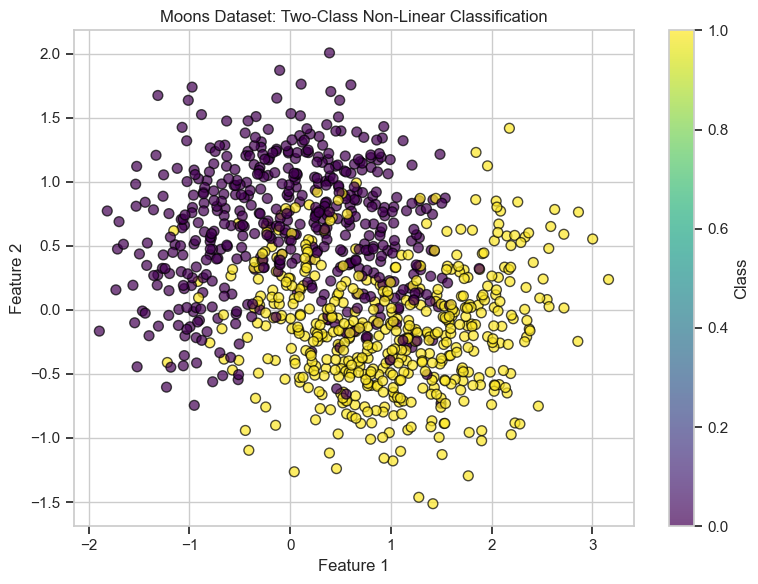

In [183]:
# Create dataset
X, y = make_moons(n_samples=1000, noise=0.4, random_state=42)

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

print(f"X shape: {X.shape} | y shape: {y.shape}")
print(f"Number of samples per class: Class 0: {(y==0).sum()}, Class 1: {(y==1).sum()}")

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=50, alpha=0.7)
plt.colorbar(scatter, label='Class')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Moons Dataset: Two-Class Non-Linear Classification')
plt.tight_layout()
plt.show()

## 2. Build a Simple Neural Network

Now we'll define our neural network architecture. We'll create a simple feedforward network with:
- **Input layer**: 2 features (x, y coordinates)
- **Hidden layer 1**: 16 neurons with ReLU activation
- **Hidden layer 2**: 8 neurons with ReLU activation
- **Output layer**: 2 neurons

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Why do we use activation functions between layers?
- What would happen if we removed all activation functions?
- Why does the output layer have 2 neurons for binary classification?
</div>

In [184]:
class SimpleNeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, num_classes):
        super(SimpleNeuralNetwork, self).__init__()
        
        # Define layers
        self.fc1 = nn.Linear(input_size, hidden_size1)   # First hidden layer
        self.relu1 = nn.ReLU()                           # Activation function
        self.fc2 = nn.Linear(hidden_size1, hidden_size2) # Second hidden layer
        self.relu2 = nn.ReLU()                           # Activation function
        self.fc3 = nn.Linear(hidden_size2, num_classes)  # Output layer
    
    def forward(self, x):
        """Forward pass through the network"""
        out = self.fc1(x)
        out = self.relu1(out)
        out = self.fc2(out)
        out = self.relu2(out)
        out = self.fc3(out)
        return out

# Initialize the model
model = SimpleNeuralNetwork(input_size=2, hidden_size1=16, hidden_size2=8, num_classes=2)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

SimpleNeuralNetwork(
  (fc1): Linear(in_features=2, out_features=16, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=16, out_features=8, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=8, out_features=2, bias=True)
)

Total parameters: 202


Now we have defined our neural network architecture! However, the coefficients (weights and biases) are still randomly initialized. Next, we will implement the forward pass to see how data flows through the network.

In [185]:
# Evaluate the initialized model on training and test data
with torch.no_grad():
    # Training data
    train_outputs = model.forward(X_train)
    _, train_predicted = torch.max(train_outputs, 1)
    train_accuracy = accuracy_score(y_train.numpy(), train_predicted.numpy())
    
    # Test data
    test_outputs = model.forward(X_test)
    _, test_predicted = torch.max(test_outputs, 1)
    test_accuracy = accuracy_score(y_test.numpy(), test_predicted.numpy())

print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Training Accuracy: 50.00%
Test Accuracy: 50.00%


## 3. Define Loss Function and Optimizer

Before we can proceed with the training, we have to define our loss function (the metric that is optimized during training), and the optimizer. The optimizer determines how  we will update the network parameters to minimize the loss.

- **Loss function (Cross-Entropy)**: Measures how well our predictions match the true labels
- **Optimizer (Adam)**: Updates the network weights using gradient descent

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- What does the learning rate control?
- What happens if the learning rate is too high? Too low?
</div>

In [186]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
learning_rate = 0.01
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print(f"Loss function: {criterion}")
print(f"Optimizer: {optimizer.__class__.__name__}")
print(f"Learning rate: {learning_rate}")

Loss function: CrossEntropyLoss()
Optimizer: Adam
Learning rate: 0.01


## 4. Train the Neural Network

Now comes the exciting part - training! We'll iterate through the data multiple times (epochs) and update the weights using backpropagation.

### Training loop breakdown:

1. **Forward pass**: Compute predictions
2. **Compute loss**: Measure prediction error
3. **Backward pass**: Compute gradients using backpropagation
4. **Update weights**: Adjust parameters using optimizer

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Why do we need `optimizer.zero_grad()`?
- What does `loss.backward()` do?
- What is an "epoch"?
</div>

In [187]:
# Training parameters
num_epochs = 100
training_loss = []
test_loss = []
training_accuracy = []
test_accuracy = []

for epoch in range(num_epochs):
    # Forward pass: compute predicted outputs (on training data)
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    
    # Backward pass: compute gradients
    optimizer.zero_grad()
    loss.backward()
    
    # Update weights
    optimizer.step()
    
    # Evaluate on train and test data
    train_outputs = model(X_train)
    train_loss_value = criterion(train_outputs, y_train)
    training_loss.append(train_loss_value.item())
    training_accuracy.append(accuracy_score(y_train.numpy(), torch.max(train_outputs, 1)[1].numpy()))
    
    test_outputs = model(X_test)
    test_loss_value = criterion(test_outputs, y_test)
    test_loss.append(test_loss_value.item())
    test_accuracy.append(accuracy_score(y_test.numpy(), torch.max(test_outputs, 1)[1].numpy()))

# Print the final losses
print(f"Final Training Loss: {training_loss[-1]:.4f}")
print(f"Final Test Loss: {test_loss[-1]:.4f}")
print(f"Final Training Accuracy: {training_accuracy[-1] * 100:.2f}%")
print(f"Final Test Accuracy: {test_accuracy[-1] * 100:.2f}%")

Final Training Loss: 0.3103
Final Test Loss: 0.3085
Final Training Accuracy: 86.50%
Final Test Accuracy: 86.00%


## 6. Visualize Training Progress

Let's plot the training and test loss/accuracy over epochs to see how the model learned.

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Does the loss decrease over time?
- Is there any sign of overfitting (training accuracy much higher than test accuracy)?
- When did the model converge (stop improving significantly)?
</div>

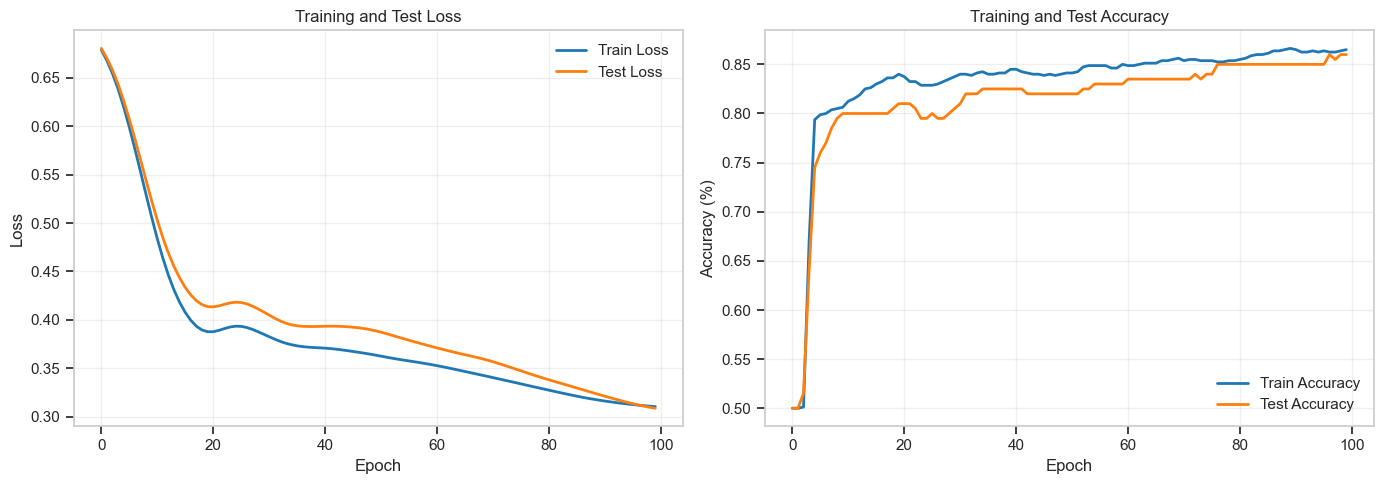

In [188]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot loss
ax1.plot(training_loss, label='Train Loss', linewidth=2)
ax1.plot(test_loss, label='Test Loss', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Test Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot accuracy
ax2.plot(training_accuracy, label='Train Accuracy', linewidth=2)
ax2.plot(test_accuracy, label='Test Accuracy', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Test Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Evaluate the Model

Now we can evaluate the final performance of our trained model on the test set. We will compute the final loss and accuracy, and plot the confusion matrix to see how well the model classified the samples.

Final Test Accuracy: 86.00%


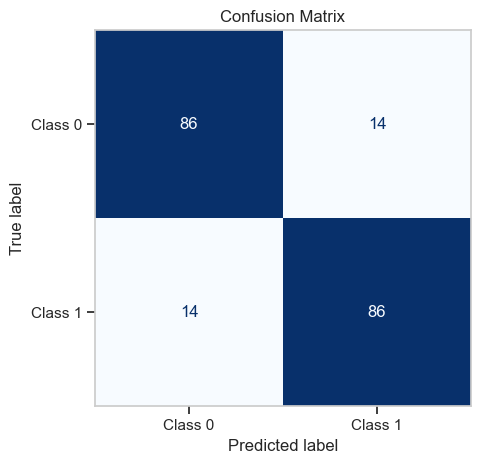

In [193]:
# Make predictions on test set
model.eval()
with torch.no_grad():
    outputs = model(X_test)
    _, y_pred = torch.max(outputs, 1)
    y_pred_np = y_pred.numpy()

# Calculate accuracy
test_accuracy = accuracy_score(y_test, y_pred_np)
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred_np)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap='Blues', values_format='d', colorbar=False)
plt.grid(False)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

### Decision Boundary Visualization

Let's visualize how the neural network separates the two classes in the feature space.

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Is the decision boundary linear or non-linear?
- How does it compare to what a linear classifier (like logistic regression) could achieve?
</div>

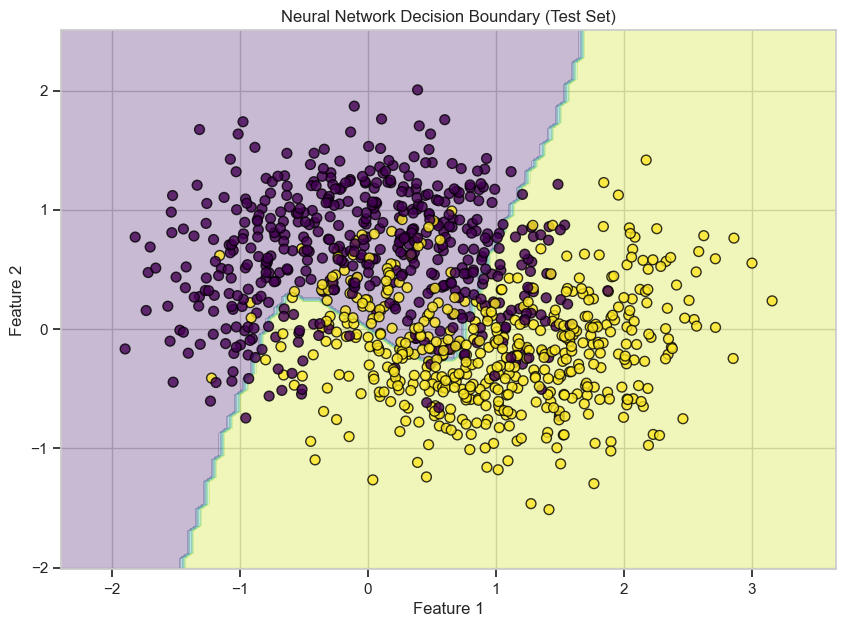

In [194]:
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    """Plot decision boundary of the neural network"""
    # Create a mesh
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    
    # Make predictions
    with torch.no_grad():
        outputs = model(grid)
        _, predictions = torch.max(outputs, 1)
        Z = predictions.numpy().reshape(xx.shape)
        
    # Plot
    plt.figure(figsize=(10, 7))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=50, alpha=0.8)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.show()

# Plot decision boundary on test set
plot_decision_boundary(model, X, y, title="Neural Network Decision Boundary (Test Set)")

## 10. Key Takeaways

Congratulations! You've built and trained your first neural network. Here's what we covered:

**Neural Network Basics:**
- Neural networks are composed of layers of neurons connected by weights
- Activation functions introduce non-linearity, allowing networks to learn complex patterns
- Common activations include ReLU, Tanh, and Sigmoid

**Training Process:**
- Forward pass: Input → Hidden layers → Output
- Compute loss: Measure difference between predictions and true labels
- Backward pass: Calculate gradients using backpropagation
- Update weights: Use optimizer (e.g., Adam) to adjust parameters

**Best Practices:**
- Always scale/normalize input features
- Split data into train/test sets to evaluate generalization
- Monitor both training and test metrics to detect overfitting
- Experiment with different architectures, learning rates, and activation functions

***
## Optional exercises (for early finishers)
### A. Build Your Own Network

Now it's your turn! Try modifying the neural network architecture and see how it affects performance.

1. Create a deeper network with 3 hidden layers (sizes: 32, 16, 8)
2. Train it for 100 epochs
3. Compare its performance to the original 2-layer network
4. Visualize the decision boundary

<div class="alert alert-block alert-info">

**Bonus challenges:**
- Try different learning rates (0.001, 0.01, 0.1)
- Experiment with different hidden layer sizes
- Try different activation functions (e.g. Tanh, Sigmoid, Leaky ReLU, etc.)
</div>

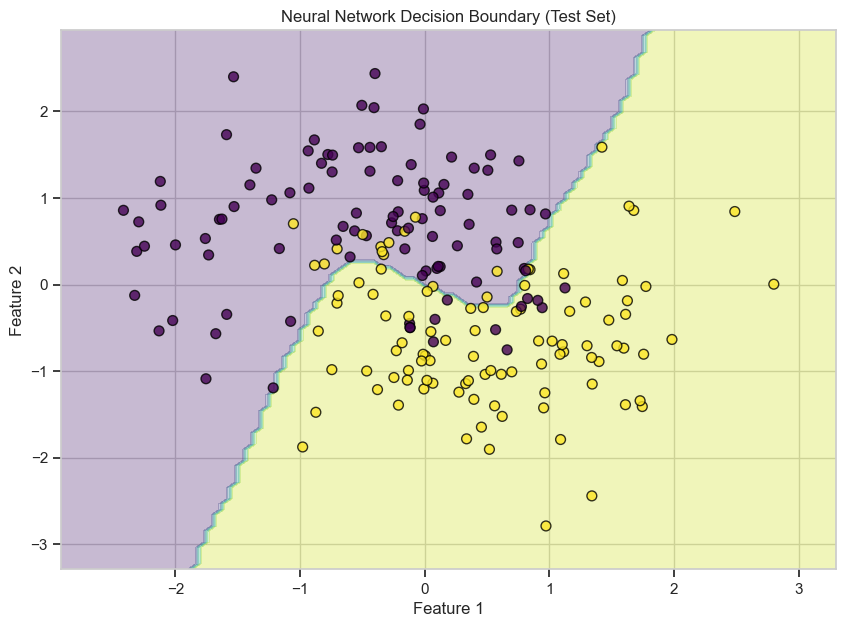

In [ ]:
# -------------------------------
# INSERT YOUR OWN CODE HERE
# -------------------------------

class CustomNeuralNetwork(nn.Module):
    def __init__(self):
        super(CustomNeuralNetwork, self).__init__()
        # Define your architecture here
        pass
    
    def forward(self, x):
        # Define forward pass here
        pass

your_custom_model = CustomNeuralNetwork()

# Train your model here

# Evaluate the trained model

# Plot the decision boundary of your model
